---
format: 
    html:
        embed-resources: true
---


# Supervised Learning: Analysis of Debts (USD) on Number of Subway Trips Made On Time

# Introduction and Motivation:
This section is about the application of supervised learning on the Debts (USD) generated from 2019 to 2023 from the MBTA transit system. 
Supervised learning is when the data has labels and the goal is to see if the model is able to predict values of data based on past/ training data.
With the application of supervised learning, we hoped to build a model that can predict whether debt can predict the number of subway trips arriving on time in the MBTA system. As well as hoping to find trends and patterns in the dataset.

## Data Preprocessing

### Regression and Multi-class Classification Decision Tree Data Processing section:

For regression and multi-class classifiaction decision tree, the debts dataset was pre-processed like the following. We selected the numerical features that had some significance from the t-tests in the eda section. So we selected the 'Debt (USD)','trip_count','Pre and Post 2021 Binary' features. We were interested to see if these features would help predict and have relation with the number of trips made on time: y - 'ontime_trip_count'.

In [41]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import tree
from IPython.display import Image
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [42]:
#load merged debts financial csv file dataset for eda
debts_dataset = pd.read_csv("../../data/processed-data/Debts_reliability_binary.csv")
#convert csv file into a dataframe
debts_df = pd.DataFrame(debts_dataset)
#print first few rows of dataframe
print(debts_df.head())
#print columns of dataframe
print(debts_df.columns)

   Unnamed: 0   Sources of Debt        Date  Debt (USD)  ontime_trip_count  \
0           0  Commercial paper  2023-06-30      125000               2925   
1           1  Commercial paper  2022-06-30       40000               3104   
2           2  Commercial paper  2021-06-30      200000               2329   
3           3  Commercial paper  2020-06-30       35000               1825   
4           4  Commercial paper  2019-06-30       50000               1914   

   trip_count         Time  Pre and Post 2021  Pre and Post 2021 Binary  
0        3297  04:00:00+00         1688083200                         1  
1        3404  04:00:00+00         1656547200                         0  
2        2727  04:00:00+00         1625011200                         0  
3        1894  04:00:00+00         1593475200                         0  
4        1999  04:00:00+00         1561852800                         0  
Index(['Unnamed: 0', 'Sources of Debt', 'Date', 'Debt (USD)',
       'ontime_trip_count

In [43]:
#drop unneeded columns
debts_df_drop = debts_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)

In [44]:
#code re-used from DSAN 5000 Lab 5.3
#set variable Y to the "target" collumn of the dataframe
Y_debt = debts_df_drop['ontime_trip_count']

#set variable X to the rest of the columns in the dataframe
X_debt = debts_df_drop[['Debt (USD)','trip_count','Pre and Post 2021 Binary']]

#print shape of Y and X to check number of rows and cols
print(Y_debt.shape)
print(X_debt.shape)

(5,)
(5, 3)


## Training and Testing Strategy

We split the data into training and test on an 80/20 split by using the train_test_splot sklearn module.

In [45]:
#code re-used from DSAN 5000 Lab 5.3
#partition debt data
from sklearn.model_selection import train_test_split

#partition dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(X_debt,Y_debt, test_size=0.2, random_state=42)

In [46]:
#code re-used from DSAN 5000 Lab 5.3
#print type and shape as check point: x_train, x_test, y_train, y_test
print(type(x_train), x_train.shape) #print type and shape of x_train set
print(type(x_test), x_test.shape) #print type and shape of x_test set
print(type(y_train), y_train.shape) #print type and shape of y_train set
print(type(y_test), y_test.shape) #print type and shape of y_test set

<class 'pandas.core.frame.DataFrame'> (4, 3)
<class 'pandas.core.frame.DataFrame'> (1, 3)
<class 'pandas.core.series.Series'> (4,)
<class 'pandas.core.series.Series'> (1,)


## Model Selection:

To meet the multi-class classification requirement, we created a classification decision tree with different classes. We decided on a classification decision tree because the model has the ability to assign data into classes and the model is eaiser to understand and works well with data that did not have lots of preparation.

After splitting the data into 80/20 training and test set, the classification decision tree splits the data on the x features into their own categories. Then the model will keep spliiting - this process repeats until the maximum depth is reached or all data are classified in the same group.

### Multi-class Classification Section:

In [47]:
#code re-used from DSAN 5000 Lab 5.3
#train sklearn decision tree model on the x-train, y_train of the net position dataset
from sklearn import tree #import tree library
model = tree.DecisionTreeClassifier() #set classifier for decision tree
debt_tree_model = model.fit(x_train, y_train) #fit decision tree model on x_train and y_train sets

In [48]:
#code re-used from DSAN 5000 Lab 5.3
#use tree model to make predictions for the training and test set
debt_y_train = debt_tree_model.predict(x_train) #make predictions for training set
debt_y_test = debt_tree_model.predict(x_test) #make predictions for test set

print(debt_y_train) #print predictions for training set
print(debt_y_test) #print predictions for test set

[1914 2329 2925 1825]
[1825]


### Regression section

To meet the regression requirement, we created a regression decision tree. We decided on a regression decision tree because the model is easy to interpret and visualize and can select the most important features used for prediction.
After splitting the debts dataset into 80/20 training and test set, the model will be able to select the best feature to split on until the data is divided into groups that are similar to each other.

In [49]:
#import skearn libraries and tree modules
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#create object that is decision tree regressor
regressor = DecisionTreeRegressor()

#train the model on the decision tree regressor
reg_tree_model = regressor.fit(x_train, y_train)

#make prediction on the test set
reg_y_pred = reg_tree_model.predict(x_test)

### Binary Classification Section

To meet the binary classification requirement, we decided to use a logistic regression tree model. The logistic regression tree can avoid overfitting and provide more useful outputs. We wanted to use this model to predict the probability of a subway trip coming on time.
After splitting the data into training and test set, the logistic regression tree model makes prediction of the outcome at the leaves of the model.

In [50]:
#import logisticRegression library
from sklearn.linear_model import LogisticRegression

#create logistic regression model
logistic = LogisticRegression()

#fit logistic regression model on the training data
logistic_model = logistic.fit(x_train, y_train)

#make prediction on the test set
log_y_pred = logistic_model.predict(x_test)

## Model Evaluation Metrics:

### Multi-Class Classification:

In [51]:
#code re-used from DSAN 5000 Lab 5.3
#function def confusion_plot(y_data,y_pred) generates a confusion matrix plot and prints information from function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #import sklearn libraries to create confusion matrix

def confusion_plot(y_data, y_pred):
    labels = np.unique(np.concatenate((Y_debt, y_pred))) #unique labels from target data and y_pred to be used for confusion matrix
    confusion_mat = confusion_matrix(y_data, y_pred, labels = labels) #create confusion matrix
    confusion_plot = ConfusionMatrixDisplay(confusion_matrix =  confusion_mat, display_labels = labels) #generate confusion matrix plot

    accuracy = accuracy_score(y_data, y_pred) #calculate accuracy score of matrix plot

    recall = recall_score(y_data, y_pred, average='macro') #calculate recall score, use average ='macro' for multi-class classification
    precision = precision_score(y_data, y_pred, average='macro') #calculated precision score, use average ='macro' for multi-class classification
    
    print("ACCURACY: ", accuracy) #print accuracy score
    print("RECALL: ", recall) #print recall score
    print("PRECISION: ", precision) #print precision score
    print(confusion_mat.shape) #print shape of confusion matrix
    print(confusion_mat) #print out the confusion matrix with labels

    confusion_plot.plot() #plot the confusion matrix
    plt.show() #show plot

------TRAINING------
ACCURACY:  1.0
RECALL:  1.0
PRECISION:  1.0
(5, 5)
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


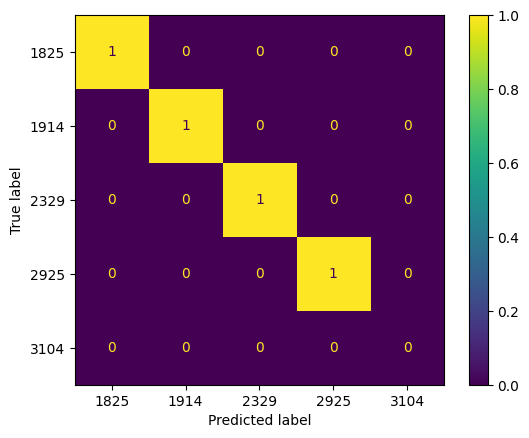

------TEST------
ACCURACY:  0.0
RECALL:  0.0
PRECISION:  0.0
(5, 5)
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


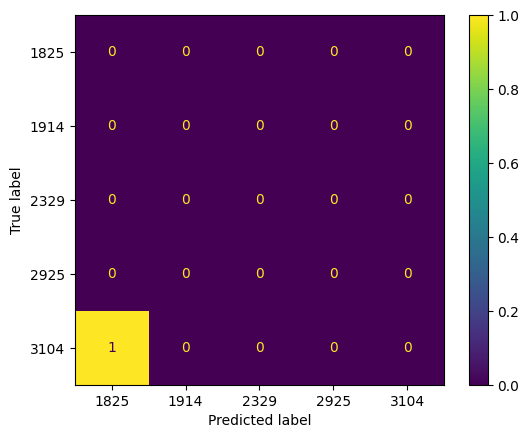

In [52]:
#code re-used from DSAN 5000 Lab 5.3
print("------TRAINING------")
confusion_plot(y_train,debt_y_train)
print("------TEST------")
confusion_plot(y_test,debt_y_test)


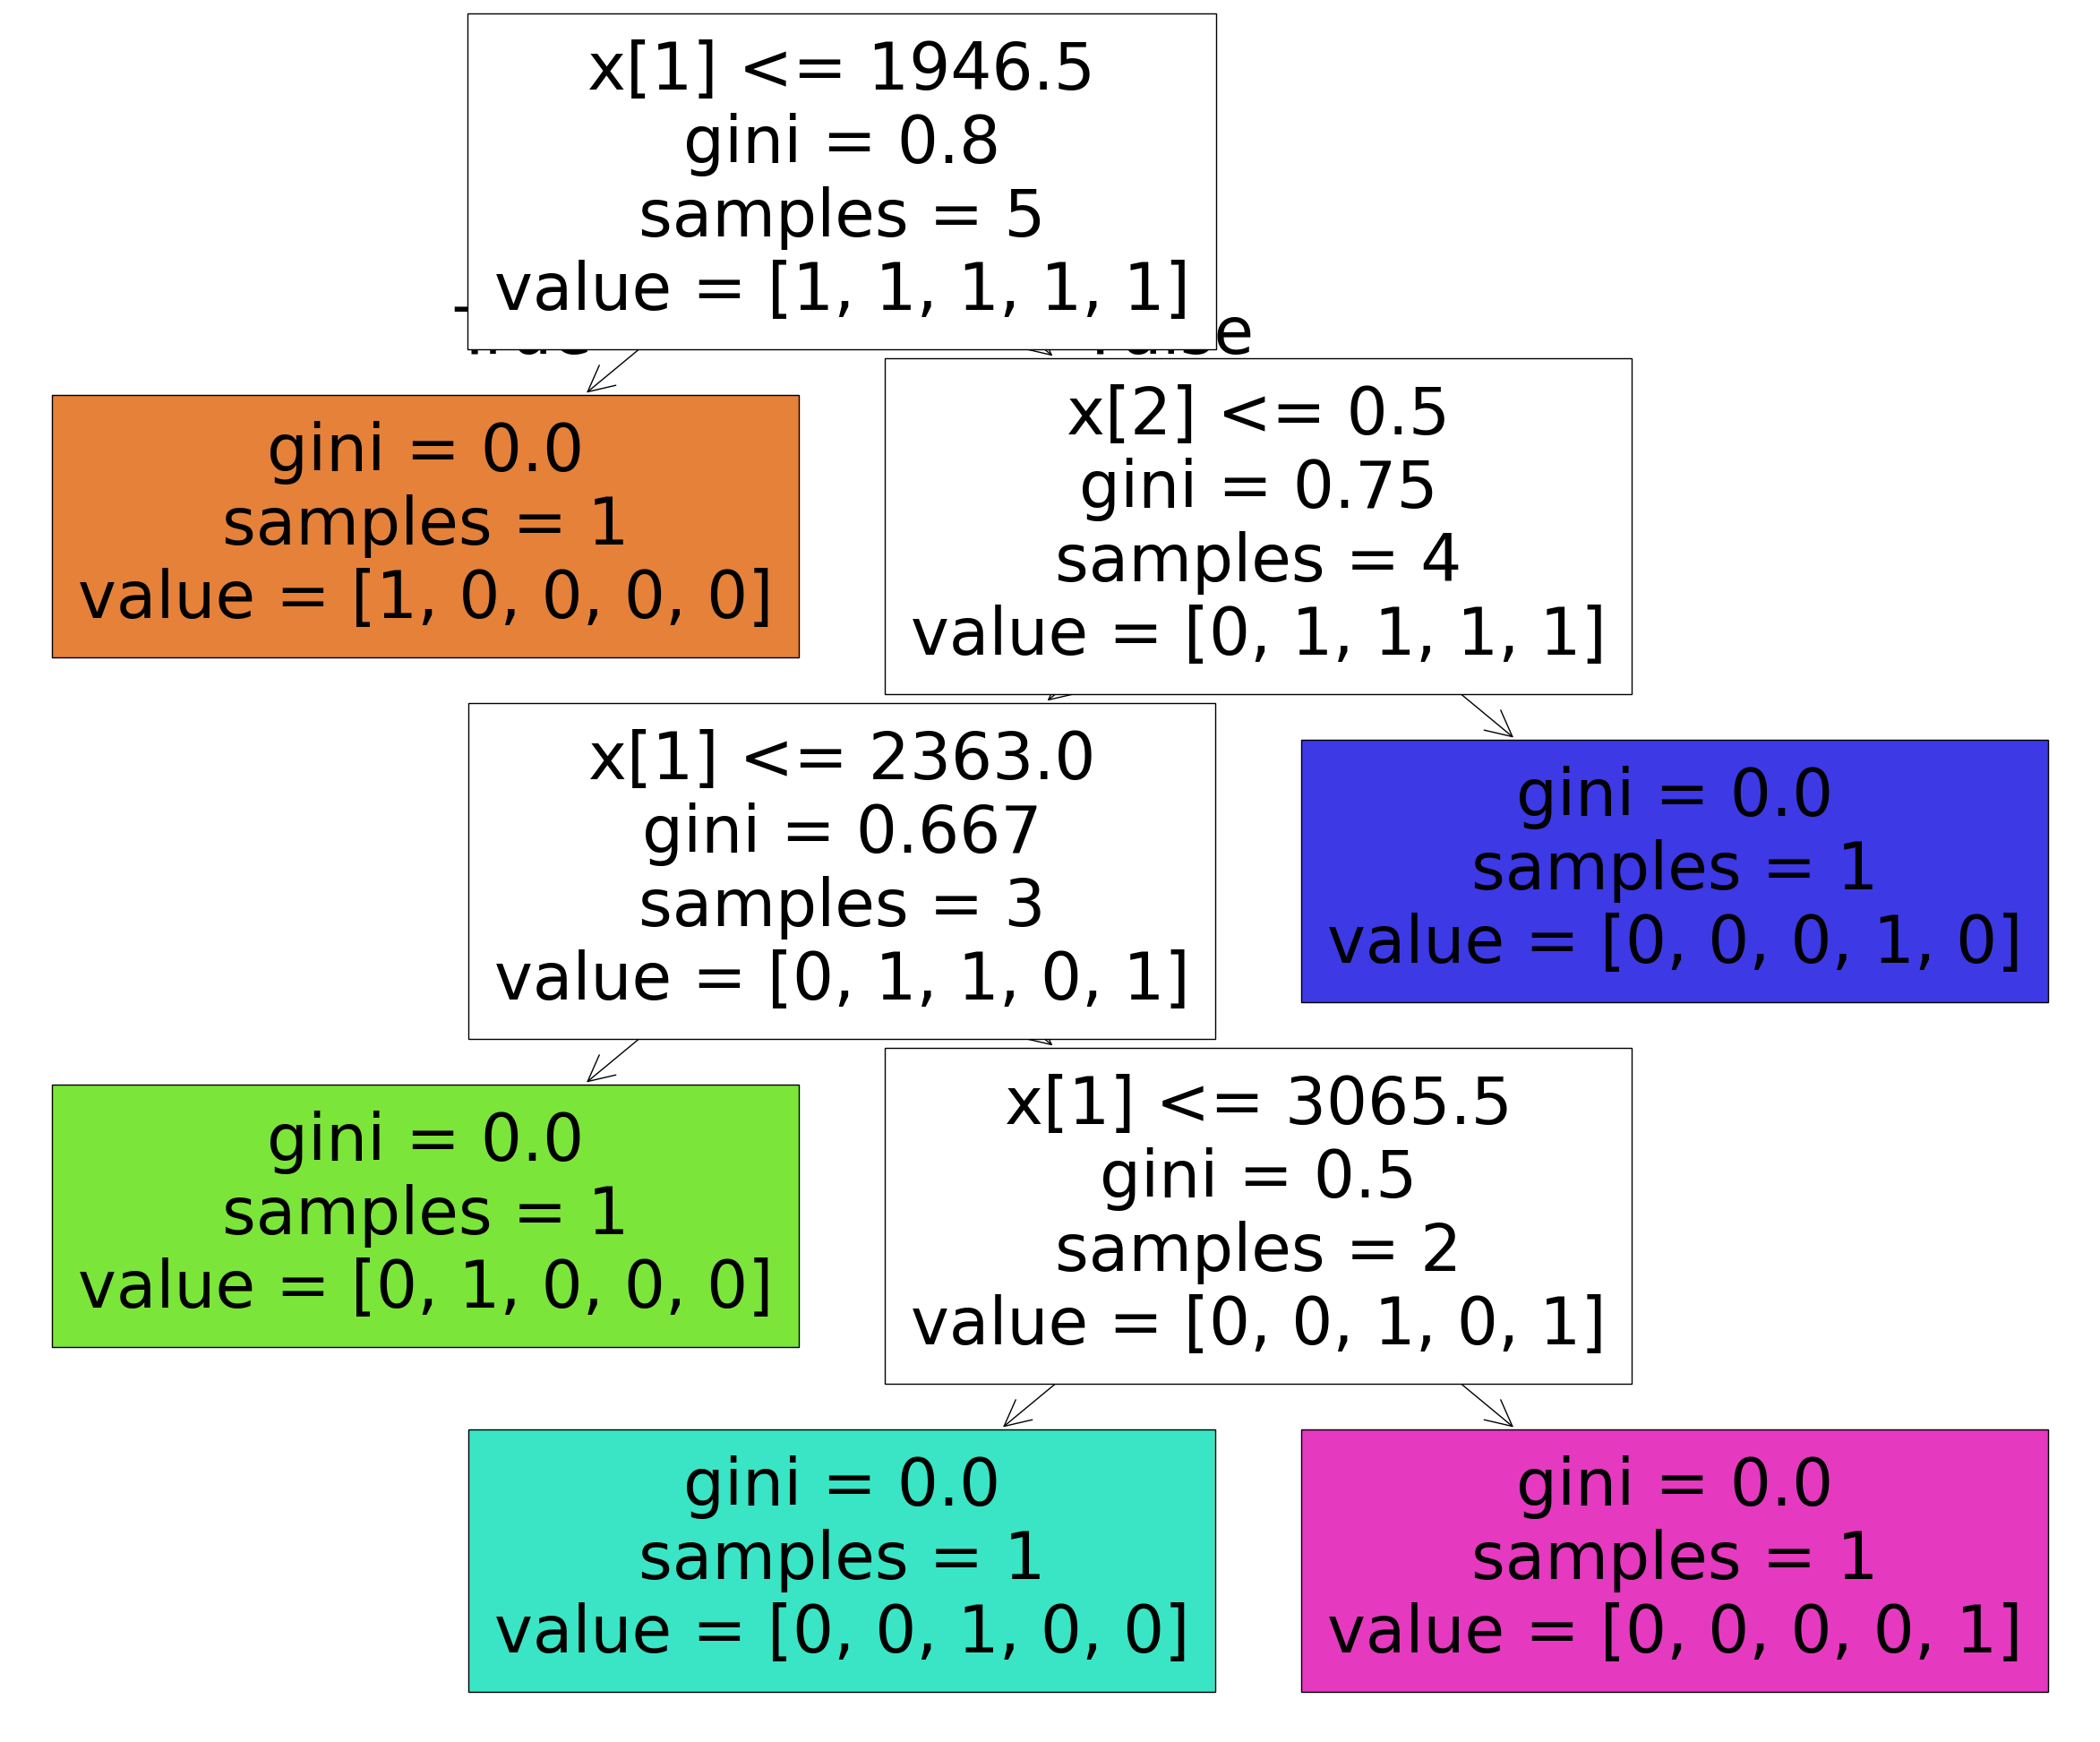

In [53]:
#code re-used from DSAN 5000 Lab 5.3
#function def plot_tree(model, X,Y) visualized the decision tree
#import sklearn libraries to make decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

def plot_tree(model, X,Y):
    model = DecisionTreeClassifier() #use classifier to create classification decision tree
    model.fit(X,Y) #fit data into decision tree classifier

    plt.figure(figsize=(30,25)) #set figure size for decision tree plot
    tree.plot_tree(model, filled=True) #plot the decision tree of data
    plt.show() #show decision tree plot


plot_tree(model, X_debt,Y_debt) #call plot_tree function


In [54]:
##code re-used from DSAN 5000 Lab 5.3
#loop over possible hyper-parameter values
debt_test_results=[] #initialize empty list to store test set results
debt_train_results=[] #initialize empty list to store train set results

for num_layer in range(1,20): #iterage over "max-depth"
    model = tree.DecisionTreeClassifier(max_depth=num_layer) #adjust max_depth hyper-parameter in the decision tree classifier
    debt_model = model.fit(x_train, y_train) #fit model on the x_train and y_train set

    debt_yp_train=debt_model.predict(x_train) #get model predictions on the x_train set
    debt_yp_test=debt_model.predict(x_test) #get model predictions on the x_test set

    debt_test_results.append([num_layer,accuracy_score(y_test, debt_yp_test),recall_score(y_test, debt_yp_test, average='macro')]) #append results of test set
    debt_train_results.append([num_layer,accuracy_score(y_train, debt_yp_train),recall_score(y_train, debt_yp_train, average='macro')]) #append results of training set


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

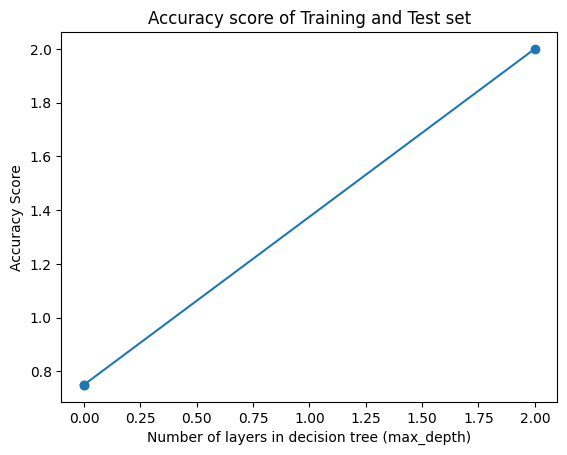

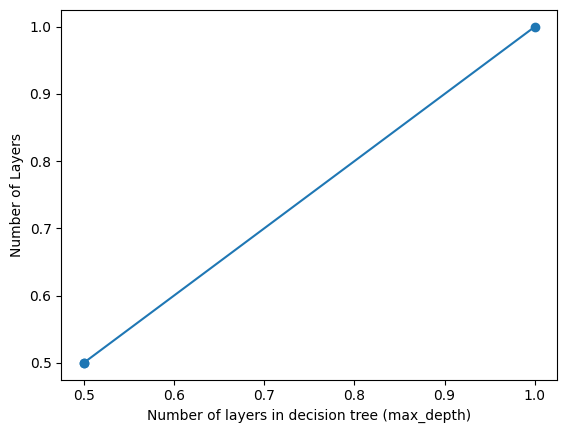

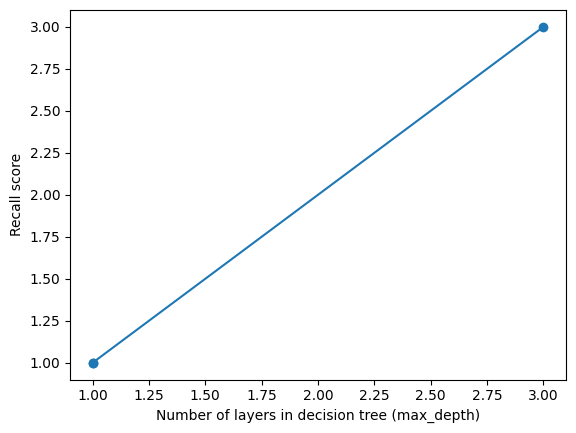

In [66]:
##code re-used from DSAN 5000 Lab 5.3
#create line plot for accuracy score for decision tree model on test set
plt.plot(debt_test_results[1], debt_train_results[1], marker='o') #plot the accuracy score value of the training and test set, extracted from the test_results and the train_results lists
plt.title("Accuracy score of Training and Test set")
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('Accuracy Score') #set y-axis label
plt.show() #show plot

#create line plot for number of layers of decision tree model on training set
plt.plot(debt_train_results[0], debt_train_results[0], marker='o') #plot the number of layers as hyperparameter for training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('Number of Layers') #set y-axis label
plt.show() #show plot

#create line plot for recall score of decision tree model on test set
plt.plot(debt_train_results[2], debt_train_results[2], marker='o') #plot the recall score value of the training and test set, extracted from the test_results and the train_results lists
plt.xlabel('Number of layers in decision tree (max_depth)') #set x-axis label
plt.ylabel('Recall score') #set y-axis label
plt.show() #show plot


In [67]:
##code re-used from DSAN 5000 Lab 5.3
#re-train the decision tree using the optimal hyper-parameter obtained from the line plots created above. Use max-depth = 2 as test to see if the tree model performance improves

model = tree.DecisionTreeClassifier(max_depth=2) #based on the three plots above, set the max_depth = 2
debt_model = model.fit(x_train, y_train) #fit model onto x_train and y_train set

debt_yp_train=debt_model.predict(x_train) #make predictions on x_train set
debt_yp_test=debt_model.predict(x_test) #make predictions on x_test set


------TRAINING------
ACCURACY:  0.75
RECALL:  0.75
PRECISION:  0.625
(5, 5)
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


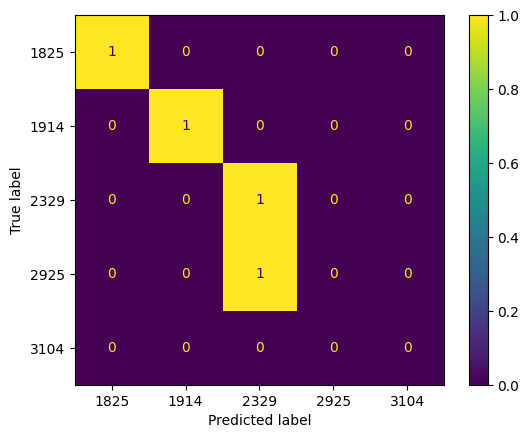

------TEST------
ACCURACY:  0.0
RECALL:  0.0
PRECISION:  0.0
(5, 5)
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]


/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/finalportfolio_dsan5000/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


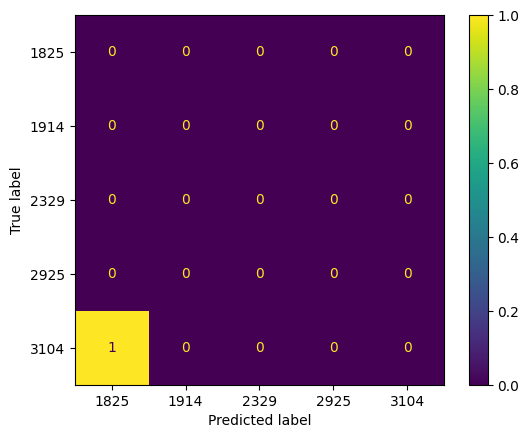

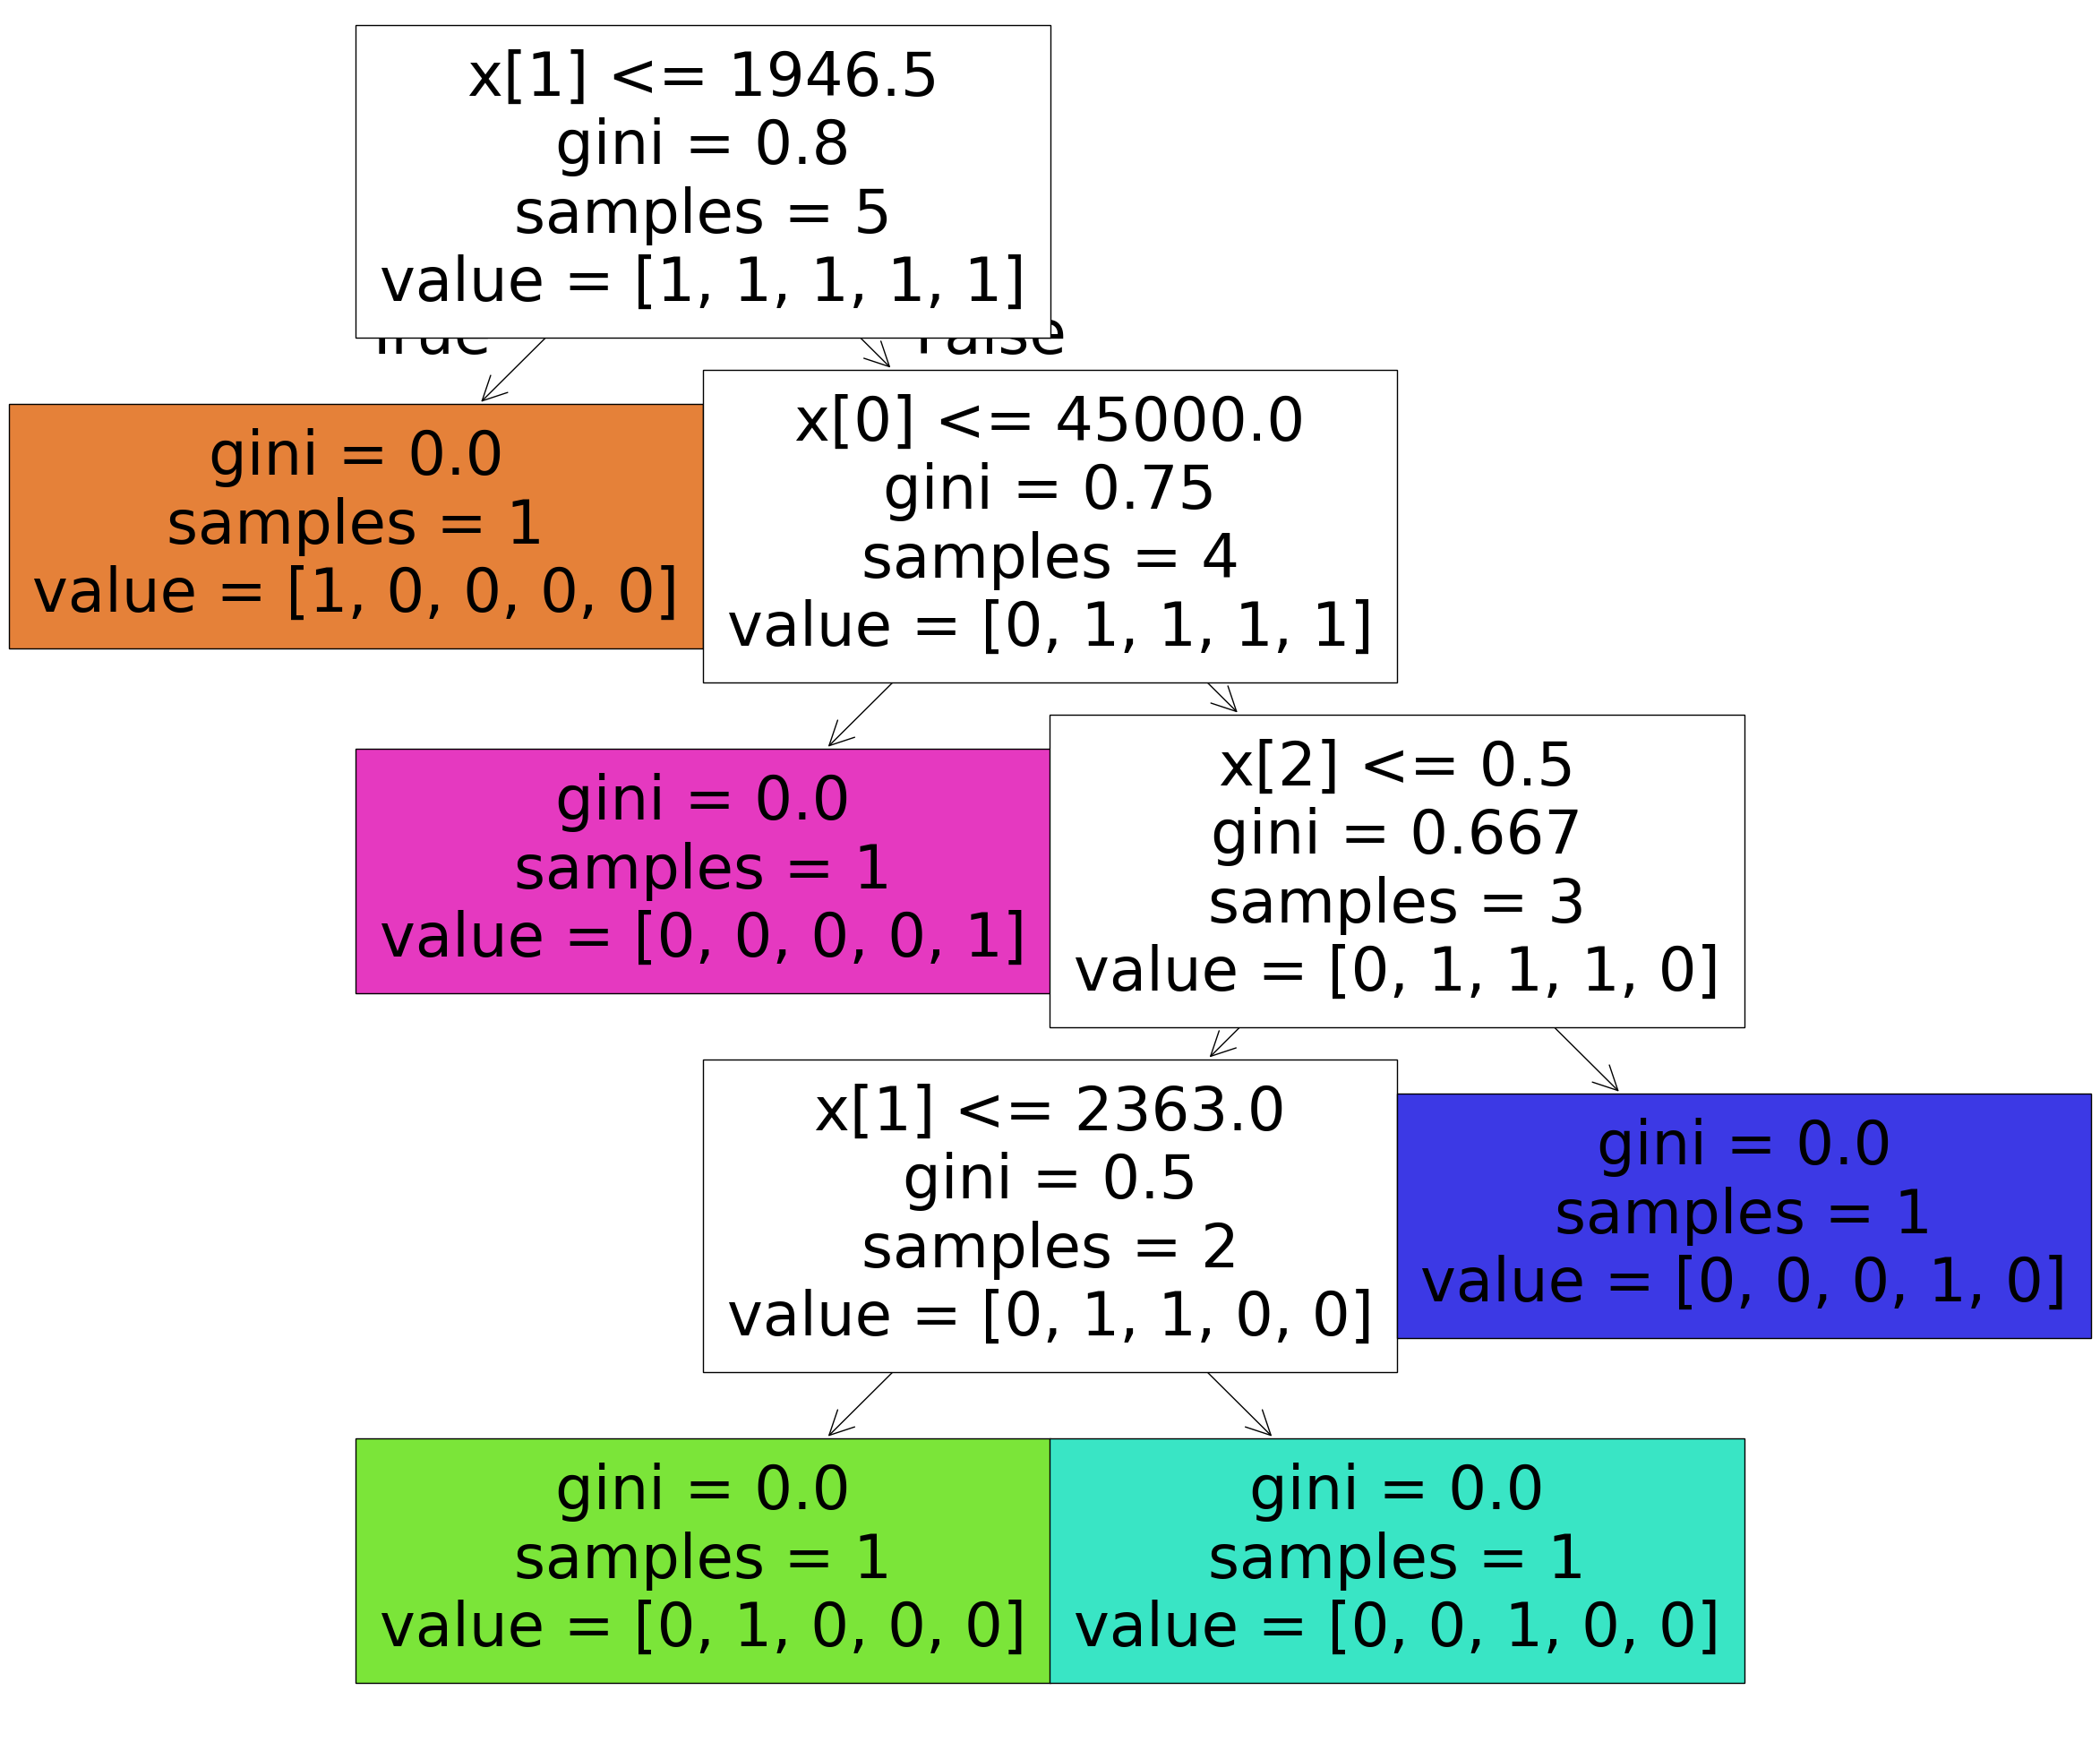

In [68]:
##code re-used from DSAN 5000 Lab 5.3
#after updating the max depth of tree model to 2 to hypertune the tree model, re-train the net position dataset to see if the hypertuning improved the tree model performance
print("------TRAINING------")
confusion_plot(y_train,debt_yp_train)
print("------TEST------")
confusion_plot(y_test,debt_yp_test)

plot_tree(debt_model,X_debt, Y_debt)


After fitting the classification decision tree model on the debts dataset, we then retrained the data based on the accuracy score to find the max depth parameter. The intial classification decision tree model had a good result for the training data where the accuracy, precision, and recall score = 1. Which implies the model predicted the positive and negative classes right and predicted positived, but the recall score also tells us that only one of the positive cases was right. The test set performed poorley because the accuracy, precision, and recall socre = 0. In addition the visual for the classification decision tree showed that the model performed okay because the gini score = 0.0 at the leaf nodes, meaning the model was set the class labels are labeled correctly.

After calculating accuracy scores, we tested with hyperparameter max-depth = 2 to see if it will improve the model performance. However, the model fit to the training set performed worse with accuracy, recall, and precision score dropping down to 0.75.

### Regression section:

In [69]:
#evaluate regression tree model
mse = mean_squared_error(y_test, reg_y_pred)
print("Mean Squared Error: ", mse)

Mean Squared Error:  1635841.0


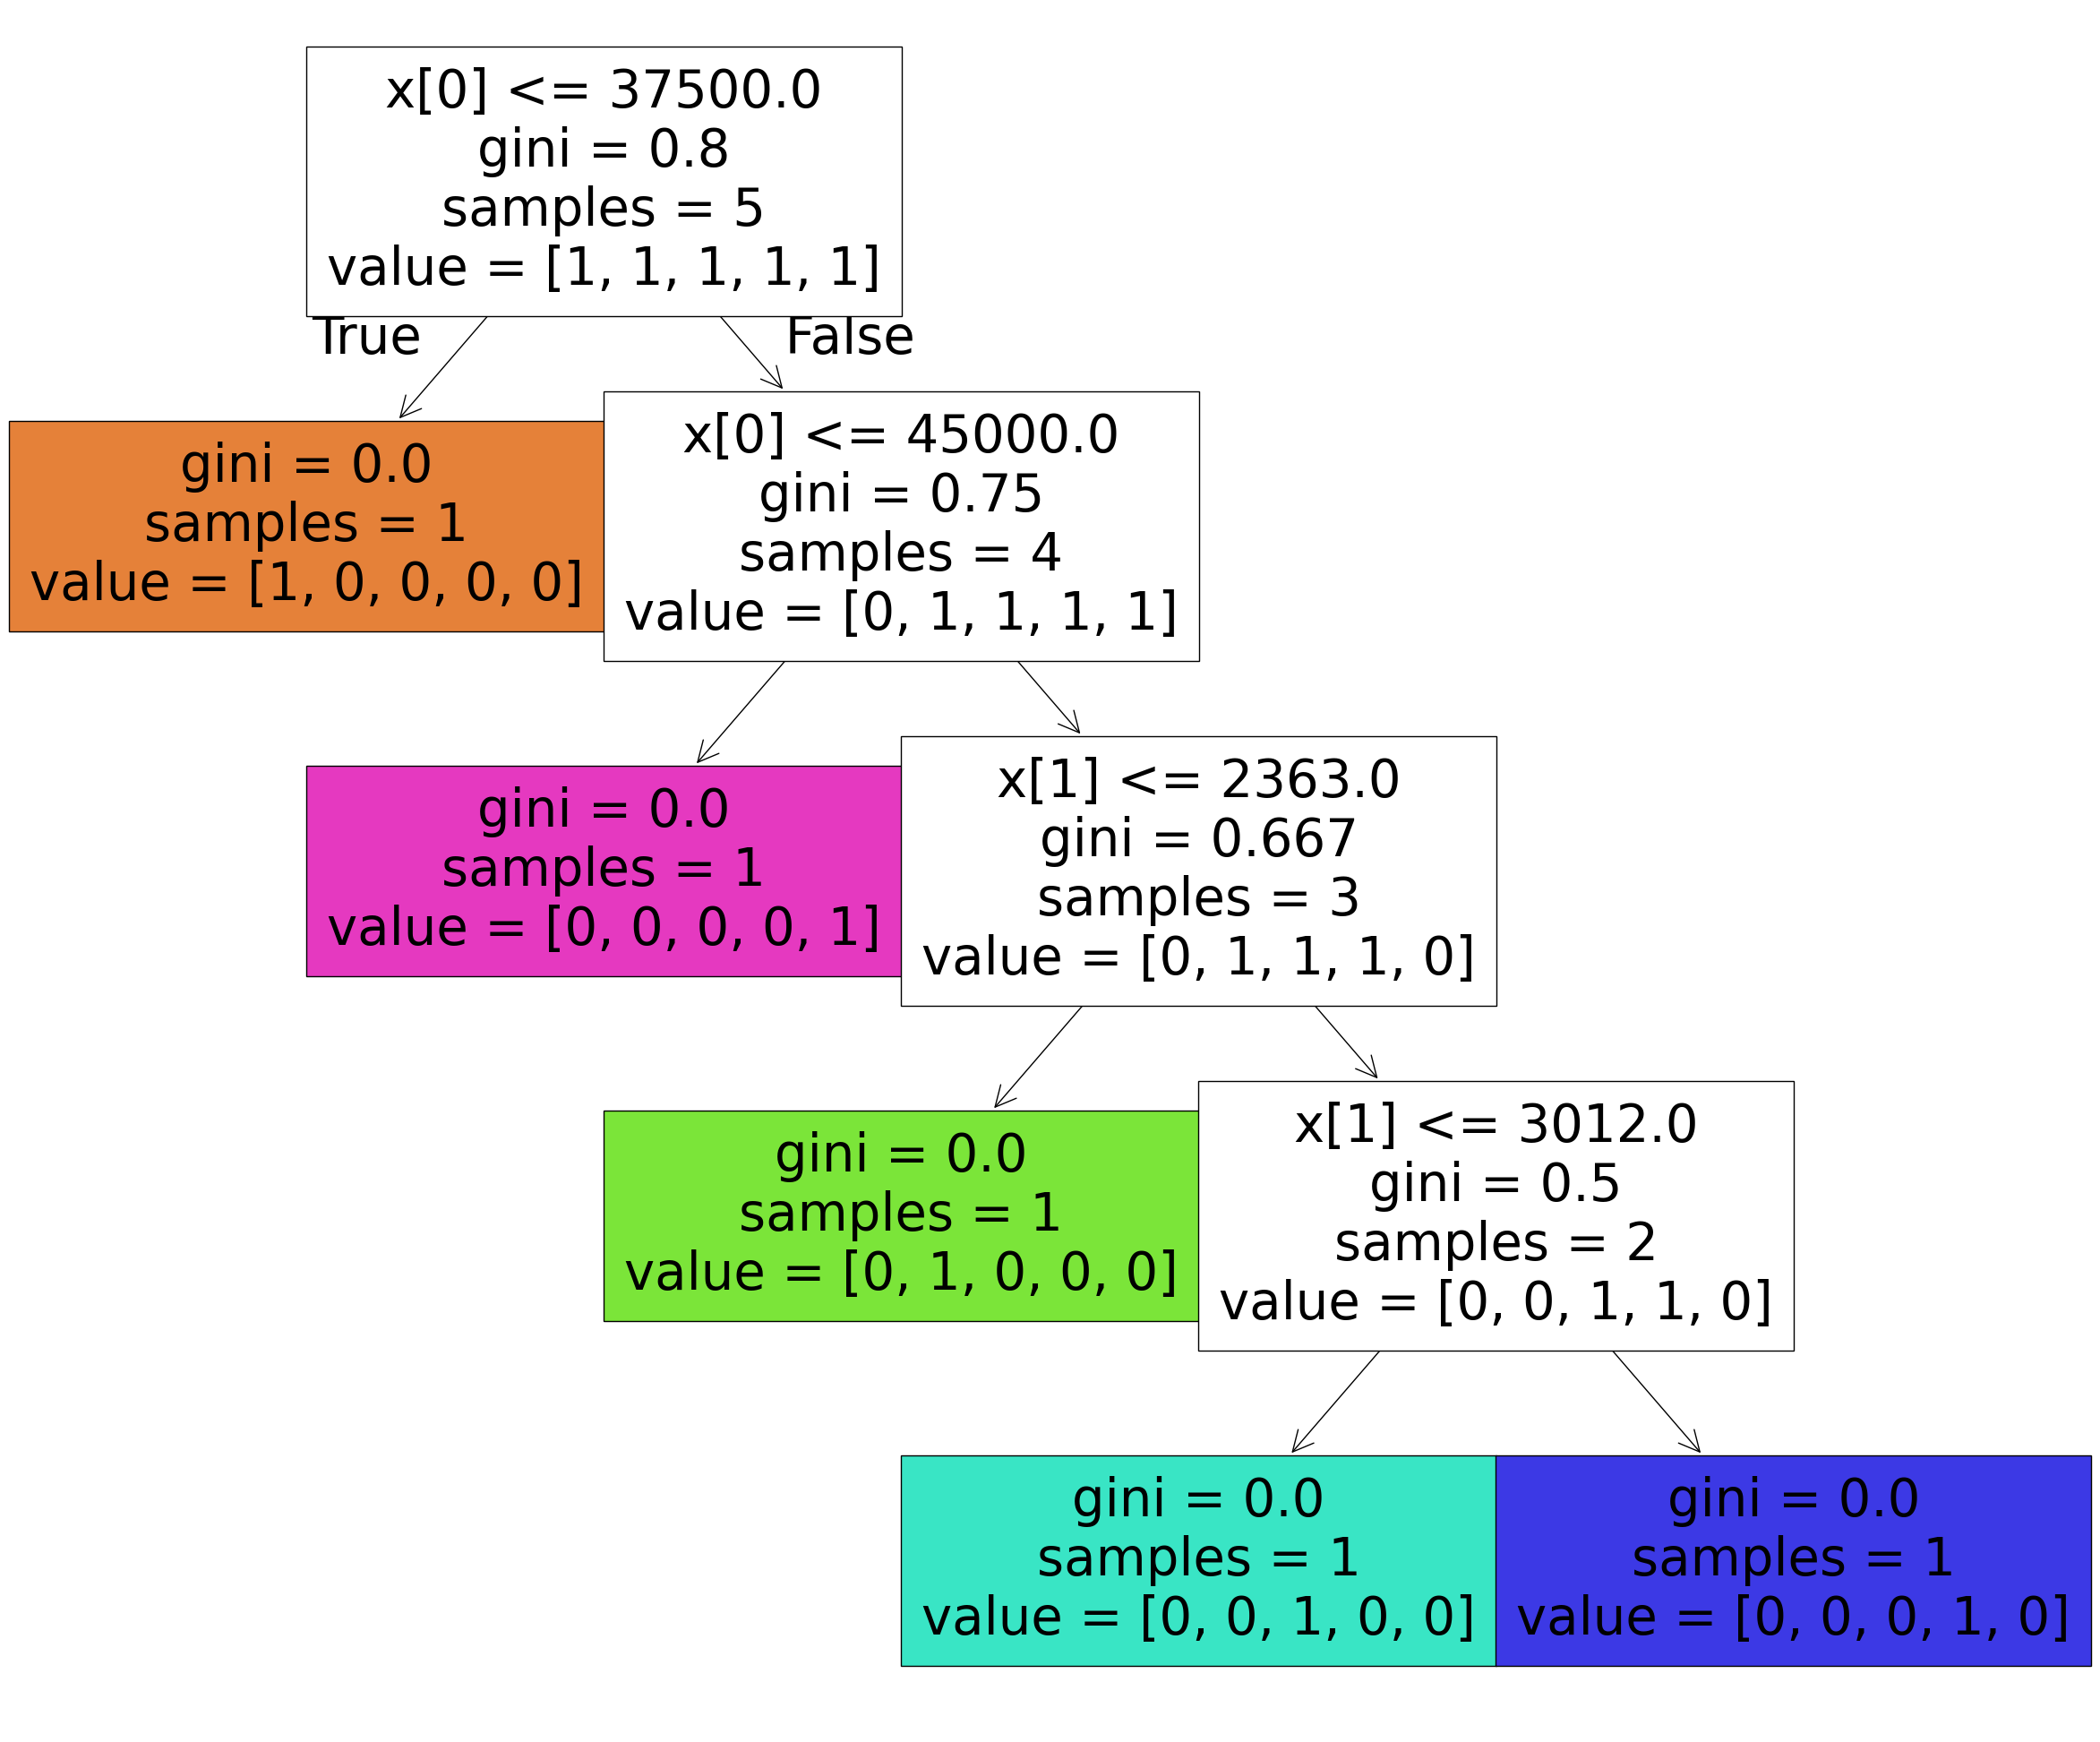

In [70]:
#visualize using regression tree model
plot_tree(reg_tree_model,X_debt, Y_debt)

The regression decision tree metric used was the mean squared error (MSE) = 1635841.0
The high MSE score tells use the model performance is poor and has large errors. Furthermore the visual of the regression decision tree performed moderate.

### Binary Classification section:

In [71]:
#get accuracy score of logistic regression model fit on the debts dataset
logistic_accuracy = accuracy_score(y_test, log_y_pred )
print("Accuracy:", logistic_accuracy)

Accuracy: 0.0


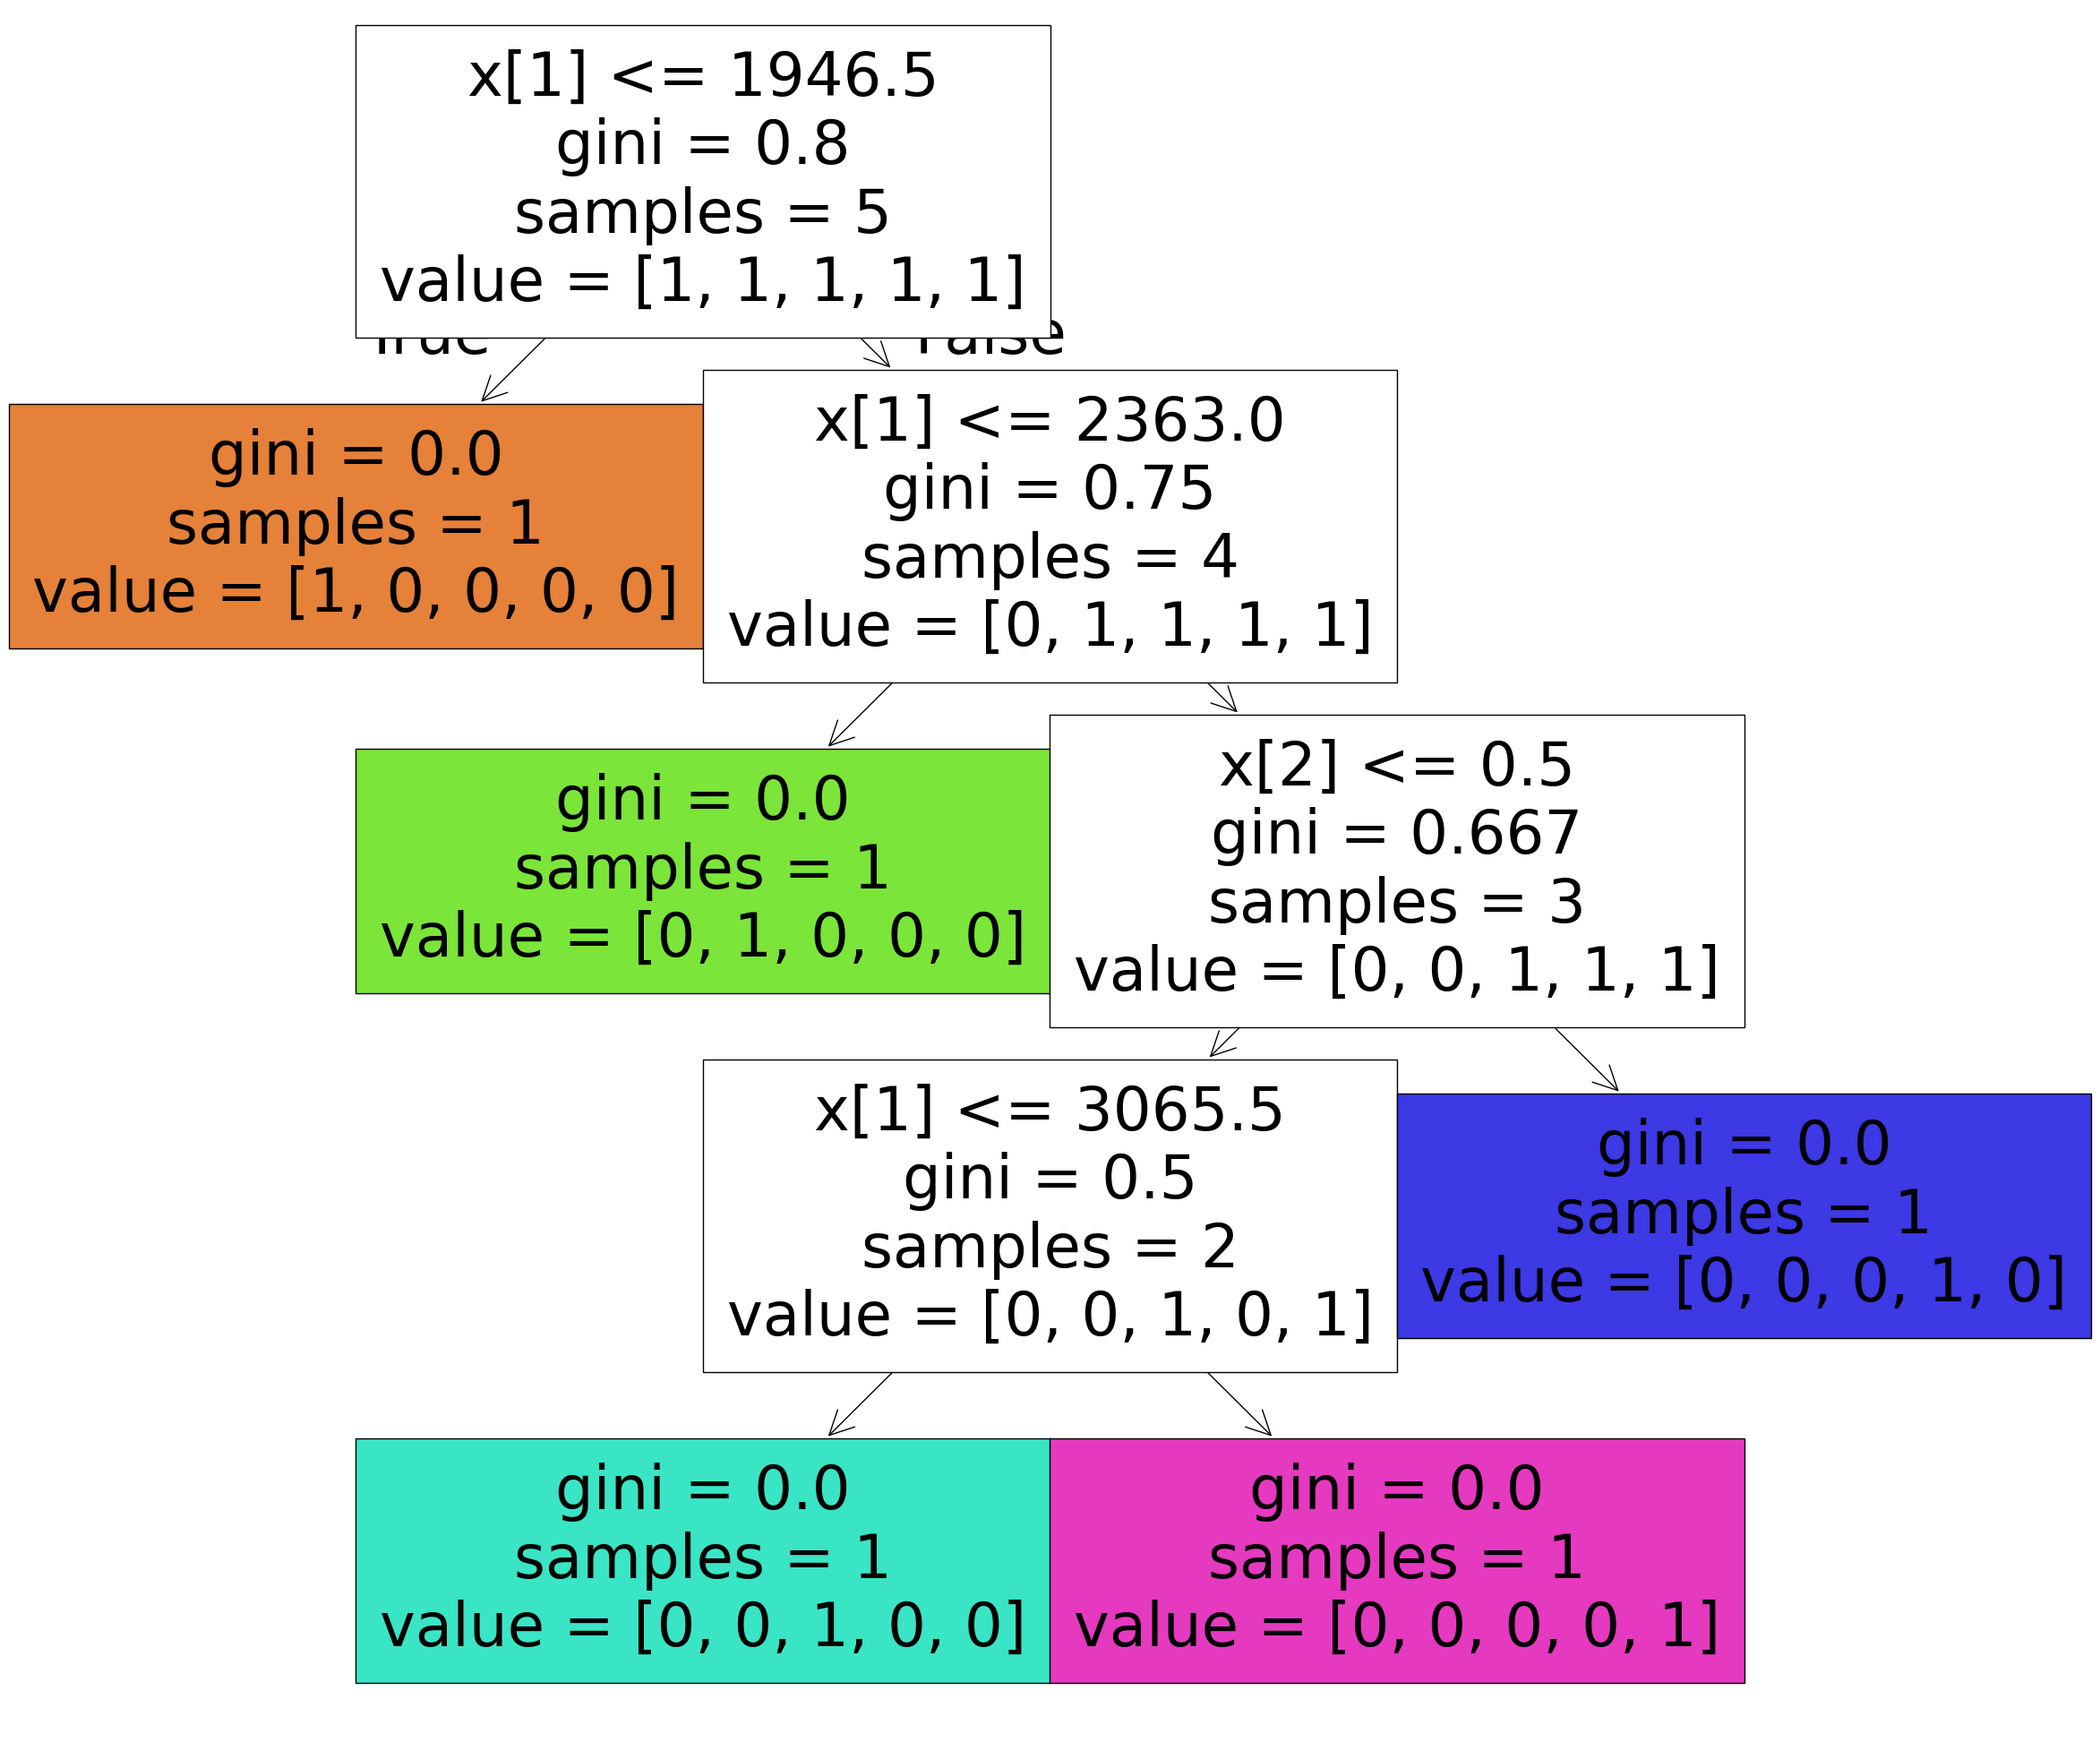

In [72]:
#visualize using regression tree model
plot_tree(logistic_model,X_debt, Y_debt)

The binary classificaton metric used for the logistic regression model was the accuracy score. This logistic regression model accuracy = 0.0, which implies that the model is not good at predicting the positive and negative classes in the debts dataset.

# Discussion

In conclusion, the multiclass classification decision tree performed the best on the debts dataset as compared to the regression decision tree model and the logistic regression tree model. 
Since the debts dataset have different sources of debts as observations, the multiclass classification decision tree model was likely the best approach in applying a supervised learning algorithm onto the debts dataset.